In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("final_full_datasetache sir.csv")

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
df.head()

Molecule ChEMBL ID  \
0        CHEMBL64011   
1      CHEMBL4283770   
2      CHEMBL4283733   
3       CHEMBL286990   
4      CHEMBL1651046   

                                                                                        Smiles  \
0                                 CN1CC[C@@]2(C)c3cc(OC(=O)NCCCCCCCCCN4CCOCC4)ccc3N(C)[C@@H]12   
1                                                       CN(C)CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1   
2                                              CCN(CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1)Cc1ccccc1   
3                                              C[n+]1ccn(COCC(C)(C)[N+](=O)[O-])c1/C=N/O.[Cl-]   
4  C[C@@H]([C@H]1[C@H](O)C[C@@]2(C)[C@@H]3CC[C@@H]4C(=CC3=CC[C@]12C)CC[C@H](N(C)C)C4(C)C)N(C)C   

   pChEMBL Value  Activity  \
0           7.22    Active   
1           6.18    Active   
2           4.65  Inactive   
3           4.97  Inactive   
4           4.53  Inactive   

                                                                              canonical_smiles  \
0                                 CN1CC[C@@]2(C)c3cc(OC(=O)NCCCCCCCCCN4CCOCC4)ccc3N(C)[C@@H]12   
1                                                       CN(C)CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1   
2                                              CCN(CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1)Cc1ccccc1   
3                                              C[n+]1ccn(COCC(C)(C)[N+](=O)[O-])c1/C=N/O.[Cl-]   
4  C[C@@H]([C@H]1[C@H](O)C[C@@]2(C)[C@@H]3CC[C@@H]4C(=CC3=CC[C@]12C)CC[C@H](N(C)C)C4(C)C)N(C)C   

     MolWt    LogP  H_Donors  H_Acceptors   TPSA  NumRotatableBonds  NumAtoms  \
0  472.674  4.2070       1.0          6.0  57.28               11.0      34.0   
1  323.392  3.2857       0.0          4.0  38.77                5.0      24.0   
2  413.517  5.2462       0.0          4.0  38.77                8.0      31.0   
3  292.723 -2.8459       1.0          5.0  93.77                6.0      19.0   
4  428.705  5.3628       1.0          3.0  26.71                3.0      31.0   

   HeavyAtomCount  NumHeteroatoms  NumCarbons  NumNitrogens  NumOxygens  \
0            34.0             7.0        27.0           4.0         3.0   
1            24.0             4.0        20.0           1.0         3.0   
2            31.0             4.0        27.0           1.0         3.0   
3            19.0             9.0        10.0           4.0         4.0   
4            31.0             3.0        28.0           2.0         1.0   

   NumHalogens  NumBonds  NumDoubleBonds  NumTripleBonds  NumRings  \
0          0.0      37.0             1.0             0.0       4.0   
1          0.0      26.0             2.0             0.0       3.0   
2          0.0      34.0             2.0             0.0       4.0   
3          1.0      18.0             2.0             0.0       1.0   
4          0.0      34.0             2.0             0.0       4.0   

   NumAromaticRings  NumAliphaticRings  NumSaturatedRings  NumAromaticAtoms  \
0               1.0                3.0                2.0               6.0   
1               2.0                1.0                0.0              12.0   
2               3.0                1.0                0.0              18.0   
3               1.0                0.0                0.0               5.0   
4               0.0                4.0                2.0               0.0   

   NumAliphaticAtoms  FractionCSP3  morgan_0  morgan_1  morgan_2  morgan_3  \
0               28.0      0.740741         0         0         0         0   
1               12.0      0.250000         0         0         0         0   
2               13.0      0.222222         0         0         0         0   
3               14.0      0.600000         0         0         0         0   
4               31.0      0.857143         0         1         0         0   

   morgan_4  morgan_5  morgan_6  morgan_7  morgan_8  morgan_9  morgan_10  \
0         0         0         0         0         0         0          0   
1         0         0         0         0  

In [4]:
df.info()   # Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5743 entries, 0 to 5742
Columns: 5148 entries, Molecule ChEMBL ID to rdk_2047
dtypes: float64(24), int64(5120), object(4)
memory usage: 225.6+ MB


In [5]:
df.shape   # No. of Features and Datapoints

(5743, 5148)

In [6]:
df = df[[c for c in df.columns if (
    'morgan' in c.lower() 
    or not any(fp in c.lower() for fp in ['rdk', 'atompair', 'maccs', 'pubchem'])
)]]

In [7]:
df

Molecule ChEMBL ID  \
0           CHEMBL64011   
1         CHEMBL4283770   
2         CHEMBL4283733   
3          CHEMBL286990   
4         CHEMBL1651046   
...                 ...   
5738      CHEMBL6134092   
5739      CHEMBL6147393   
5740      CHEMBL6132963   
5741      CHEMBL6148088   
5742      CHEMBL6148509   

                                                                                           Smiles  \
0                                    CN1CC[C@@]2(C)c3cc(OC(=O)NCCCCCCCCCN4CCOCC4)ccc3N(C)[C@@H]12   
1                                                          CN(C)CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1   
2                                                 CCN(CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1)Cc1ccccc1   
3                                                 C[n+]1ccn(COCC(C)(C)[N+](=O)[O-])c1/C=N/O.[Cl-]   
4     C[C@@H]([C@H]1[C@H](O)C[C@@]2(C)[C@@H]3CC[C@@H]4C(=CC3=CC[C@]12C)CC[C@H](N(C)C)C4(C)C)N(C)C   
...                                                                                           ...   
5738                                            COc1ccc2c3c1O[C@H]1C[C@@H](O)C=C[C@@]31CCN(C=O)C2   
5739                                               O=C1c2c(sc3c2CCCCC3)OC(c2ccc(Cl)cc2)N1c1ccccc1   
5740                                                   O=c1c2nc(-c3ccc(C(F)(F)F)cc3)sc2nc2n1CCCC2   
5741                                     COc1cc2c(cc1OCCCCCC1CCSS1)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2   
5742                                               COc1c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc(F)c(N)c1Br   

      pChEMBL Value  Activity  \
0              7.22    Active   
1              6.18    Active   
2              4.65  Inactive   
3              4.97  Inactive   
4              4.53  Inactive   
...             ...       ...   
5738           4.00  Inactive   
5739           6.26    Active   
5740           5.78    Active   
5741           8.12    Active   
5742           6.51    Active   

                                                                                 canonical_smiles  \
0                                    CN1CC[C@@]2(C)c3cc(OC(=O)NCCCCCCCCCN4CCOCC4)ccc3N(C)[C@@H]12   
1                                                          CN(C)CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1   
2                                                 CCN(CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1)Cc1ccccc1   
3                                                 C[n+]1ccn(COCC(C)(C)[N+](=O)[O-])c1/C=N/O.[Cl-]   
4     C[C@@H]([C@H]1[C@H](O)C[C@@]2(C)[C@@H]3CC[C@@H]4C(=CC3=CC[C@]12C)CC[C@H](N(C)C)C4(C)C)N(C)C   
...                                                                                           ...   
5738                                            COc1ccc2c3c1O[C@H]1C[C@@H](O)C=C[C@@]31CCN(C=O)C2   
5739                                               O=C1c2c(sc3c2CCCCC3)OC(c2ccc(Cl)cc2)N1c1ccccc1   
5740                                                   O=c1c2nc(-c3ccc(C(F)(F)F)cc3)sc2nc2n1CCCC2   
5741                                     COc1cc2c(cc1OCCCCCC1CCSS1)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2   
5742                                               COc1c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc(F)c(N)c1Br   

        MolWt    LogP  H_Donors  H_Acceptors   TPSA  NumRotatableBonds  \
0     472.674  4.2070       1.0          6.0  57.28               11.0   
1     323.392  3.2857       0.0          4.0  38.77                5.0   
2     413.517  5.2462       0.0          4.0  38.77                8.0   
3     292.723 -2.8459       1.0          5.0  93.77                6.0   
4     428.705  5.3628       1.0          3.0  26.71                3.0   
...       ...     ...       ...          ...    ...                ...   
5738  301.342  1.3769       1.0          4.0  59.00                2.0   
5739  409.938  6.4084       0.0          3.0  29.54                2.0   
5740  351.353  3.8751       0.0          4.0  47.78                1.0   
5741  539.807  7.4454       0.0          6.0  38.77               12.0   
5742  455.412  5.4342       1.0          4.

# eliminting xeros

In [8]:
# Calculate sum of numeric features only
feature_sum = df.sum(numeric_only=True)

# Find features with sum = 0
zero_features = feature_sum[feature_sum == 0].index

# Remove those features
df = df.drop(columns=zero_features)

print("Removed columnsache sir:", len(zero_features))

Removed columnsache sir: 4


In [9]:
df

Molecule ChEMBL ID  \
0           CHEMBL64011   
1         CHEMBL4283770   
2         CHEMBL4283733   
3          CHEMBL286990   
4         CHEMBL1651046   
...                 ...   
5738      CHEMBL6134092   
5739      CHEMBL6147393   
5740      CHEMBL6132963   
5741      CHEMBL6148088   
5742      CHEMBL6148509   

                                                                                           Smiles  \
0                                    CN1CC[C@@]2(C)c3cc(OC(=O)NCCCCCCCCCN4CCOCC4)ccc3N(C)[C@@H]12   
1                                                          CN(C)CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1   
2                                                 CCN(CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1)Cc1ccccc1   
3                                                 C[n+]1ccn(COCC(C)(C)[N+](=O)[O-])c1/C=N/O.[Cl-]   
4     C[C@@H]([C@H]1[C@H](O)C[C@@]2(C)[C@@H]3CC[C@@H]4C(=CC3=CC[C@]12C)CC[C@H](N(C)C)C4(C)C)N(C)C   
...                                                                                           ...   
5738                                            COc1ccc2c3c1O[C@H]1C[C@@H](O)C=C[C@@]31CCN(C=O)C2   
5739                                               O=C1c2c(sc3c2CCCCC3)OC(c2ccc(Cl)cc2)N1c1ccccc1   
5740                                                   O=c1c2nc(-c3ccc(C(F)(F)F)cc3)sc2nc2n1CCCC2   
5741                                     COc1cc2c(cc1OCCCCCC1CCSS1)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2   
5742                                               COc1c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc(F)c(N)c1Br   

      pChEMBL Value  Activity  \
0              7.22    Active   
1              6.18    Active   
2              4.65  Inactive   
3              4.97  Inactive   
4              4.53  Inactive   
...             ...       ...   
5738           4.00  Inactive   
5739           6.26    Active   
5740           5.78    Active   
5741           8.12    Active   
5742           6.51    Active   

                                                                                 canonical_smiles  \
0                                    CN1CC[C@@]2(C)c3cc(OC(=O)NCCCCCCCCCN4CCOCC4)ccc3N(C)[C@@H]12   
1                                                          CN(C)CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1   
2                                                 CCN(CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1)Cc1ccccc1   
3                                                 C[n+]1ccn(COCC(C)(C)[N+](=O)[O-])c1/C=N/O.[Cl-]   
4     C[C@@H]([C@H]1[C@H](O)C[C@@]2(C)[C@@H]3CC[C@@H]4C(=CC3=CC[C@]12C)CC[C@H](N(C)C)C4(C)C)N(C)C   
...                                                                                           ...   
5738                                            COc1ccc2c3c1O[C@H]1C[C@@H](O)C=C[C@@]31CCN(C=O)C2   
5739                                               O=C1c2c(sc3c2CCCCC3)OC(c2ccc(Cl)cc2)N1c1ccccc1   
5740                                                   O=c1c2nc(-c3ccc(C(F)(F)F)cc3)sc2nc2n1CCCC2   
5741                                     COc1cc2c(cc1OCCCCCC1CCSS1)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2   
5742                                               COc1c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc(F)c(N)c1Br   

        MolWt    LogP  H_Donors  H_Acceptors   TPSA  NumRotatableBonds  \
0     472.674  4.2070       1.0          6.0  57.28               11.0   
1     323.392  3.2857       0.0          4.0  38.77                5.0   
2     413.517  5.2462       0.0          4.0  38.77                8.0   
3     292.723 -2.8459       1.0          5.0  93.77                6.0   
4     428.705  5.3628       1.0          3.0  26.71                3.0   
...       ...     ...       ...          ...    ...                ...   
5738  301.342  1.3769       1.0          4.0  59.00                2.0   
5739  409.938  6.4084       0.0          3.0  29.54                2.0   
5740  351.353  3.8751       0.0          4.0  47.78                1.0   
5741  539.807  7.4454       0.0          6.0  38.77               12.0   
5742  455.412  5.4342       1.0          4.

# missing values

In [10]:
df.isnull().sum()

Molecule ChEMBL ID    0
Smiles                0
pChEMBL Value         0
Activity              0
canonical_smiles      0
                     ..
morgan_2043           0
morgan_2044           0
morgan_2045           0
morgan_2046           0
morgan_2047           0
Length: 2072, dtype: int64

In [11]:
# Drop rows with missing values
df = df.dropna().reset_index(drop=True)

print("New shape:", df.shape)

New shape: (5743, 2072)


In [12]:
df = df.drop_duplicates(subset = ['Molecule ChEMBL ID', 'canonical_smiles'])

In [13]:
df.drop(['Molecule ChEMBL ID', 'canonical_smiles'], axis = 1, inplace = True)

In [14]:
df

Smiles  \
0                                    CN1CC[C@@]2(C)c3cc(OC(=O)NCCCCCCCCCN4CCOCC4)ccc3N(C)[C@@H]12   
1                                                          CN(C)CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1   
2                                                 CCN(CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1)Cc1ccccc1   
3                                                 C[n+]1ccn(COCC(C)(C)[N+](=O)[O-])c1/C=N/O.[Cl-]   
4     C[C@@H]([C@H]1[C@H](O)C[C@@]2(C)[C@@H]3CC[C@@H]4C(=CC3=CC[C@]12C)CC[C@H](N(C)C)C4(C)C)N(C)C   
...                                                                                           ...   
5738                                            COc1ccc2c3c1O[C@H]1C[C@@H](O)C=C[C@@]31CCN(C=O)C2   
5739                                               O=C1c2c(sc3c2CCCCC3)OC(c2ccc(Cl)cc2)N1c1ccccc1   
5740                                                   O=c1c2nc(-c3ccc(C(F)(F)F)cc3)sc2nc2n1CCCC2   
5741                                     COc1cc2c(cc1OCCCCCC1CCSS1)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2   
5742                                               COc1c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc(F)c(N)c1Br   

      pChEMBL Value  Activity    MolWt    LogP  H_Donors  H_Acceptors   TPSA  \
0              7.22    Active  472.674  4.2070       1.0          6.0  57.28   
1              6.18    Active  323.392  3.2857       0.0          4.0  38.77   
2              4.65  Inactive  413.517  5.2462       0.0          4.0  38.77   
3              4.97  Inactive  292.723 -2.8459       1.0          5.0  93.77   
4              4.53  Inactive  428.705  5.3628       1.0          3.0  26.71   
...             ...       ...      ...     ...       ...          ...    ...   
5738           4.00  Inactive  301.342  1.3769       1.0          4.0  59.00   
5739           6.26    Active  409.938  6.4084       0.0          3.0  29.54   
5740           5.78    Active  351.353  3.8751       0.0          4.0  47.78   
5741           8.12    Active  539.807  7.4454       0.0          6.0  38.77   
5742           6.51    Active  455.412  5.4342       1.0          4.0  55.56   

      NumRotatableBonds  NumAtoms  HeavyAtomCount  NumHeteroatoms  NumCarbons  \
0                  11.0      34.0            34.0             7.0        27.0   
1                   5.0      24.0            24.0             4.0        20.0   
2                   8.0      31.0            31.0             4.0        27.0   
3                   6.0      19.0            19.0             9.0        10.0   
4                   3.0      31.0            31.0             3.0        28.0   
...                 ...       ...             ...             ...         ...   
5738                2.0      22.0            22.0             5.0        17.0   
5739                2.0      28.0            28.0             5.0        23.0   
5740                1.0      24.0            24.0             8.0        16.0   
5741               12.0      37.0            37.0             6.0        31.0   
5742                7.0      28.0            28.0             6.0        22.0   

      NumNitrogens  NumOxygens  NumHalogens  NumBonds  NumDoubleBonds  \
0              4.0         3.0          0.0      37.0             1.0   
1              1.0         3.0          0.0      26.0             2.0   
2              1.0         3.0          0.0      34.0             2.0   
3              4.0         4.0          1.0      18.0             2.0   
4              2.0         1.0          0.0      34.0             2.0   
...            ...         ...          ...       ...             ...   
5738           1.0         4.0          0.0      25.0             2.0   
5739           1.0         2.0          1.0      32.0             1.0   
5740           3.0         1.0          3.0      27.0             1.0   
5741           1.0         3.0          0.0      41.0             1.0   
5742           2.0         2.0          2.0      30.0             1.0   

      NumTripleBonds  NumRings  NumAromaticRings  NumAliphaticRings

# label encoding

In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Activity"] = le.fit_transform(df["Activity"])

In [17]:
df['Activity'].value_counts()

Activity
0    4625
1    1118
Name: count, dtype: int64

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

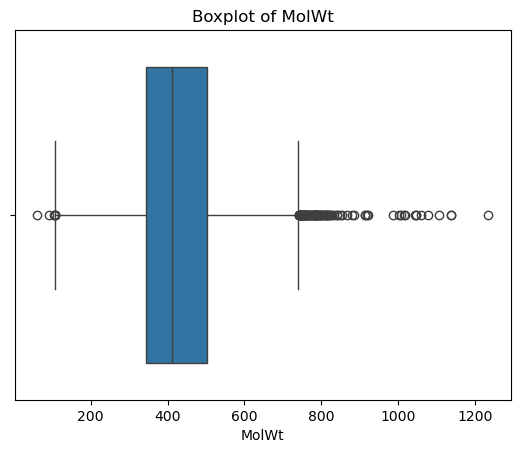

In [19]:
sns.boxplot (x =df ['MolWt'])
plt.title ("Boxplot of MolWt")
plt.show()

In [20]:
numeric_cols = ["MolWt", "LogP", "H_Acceptors","H_Donors", "TPSA","NumRotatableBonds"]

Outliers ={}
for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        
        IQR = Q3 - Q1
         
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR 
        
        Outliers[col]=df[(df[col]<lower)| (df[col]>upper)]
        
        print (f"{col} : {len(Outliers [col])} outlier detected")

MolWt : 101 outlier detected
LogP : 242 outlier detected
H_Acceptors : 33 outlier detected
H_Donors : 31 outlier detected
TPSA : 114 outlier detected
NumRotatableBonds : 137 outlier detected


# removing outliers

In [21]:
df = df[(df[col] >= lower) & (df[col] <= upper)]
df

Smiles  \
0                                    CN1CC[C@@]2(C)c3cc(OC(=O)NCCCCCCCCCN4CCOCC4)ccc3N(C)[C@@H]12   
1                                                          CN(C)CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1   
2                                                 CCN(CCOc1ccc(/C=C2\COc3ccccc3C2=O)cc1)Cc1ccccc1   
3                                                 C[n+]1ccn(COCC(C)(C)[N+](=O)[O-])c1/C=N/O.[Cl-]   
4     C[C@@H]([C@H]1[C@H](O)C[C@@]2(C)[C@@H]3CC[C@@H]4C(=CC3=CC[C@]12C)CC[C@H](N(C)C)C4(C)C)N(C)C   
...                                                                                           ...   
5738                                            COc1ccc2c3c1O[C@H]1C[C@@H](O)C=C[C@@]31CCN(C=O)C2   
5739                                               O=C1c2c(sc3c2CCCCC3)OC(c2ccc(Cl)cc2)N1c1ccccc1   
5740                                                   O=c1c2nc(-c3ccc(C(F)(F)F)cc3)sc2nc2n1CCCC2   
5741                                     COc1cc2c(cc1OCCCCCC1CCSS1)C(=O)C(CC1CCN(Cc3ccccc3)CC1)C2   
5742                                               COc1c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc(F)c(N)c1Br   

      pChEMBL Value  Activity    MolWt    LogP  H_Donors  H_Acceptors   TPSA  \
0              7.22         0  472.674  4.2070       1.0          6.0  57.28   
1              6.18         0  323.392  3.2857       0.0          4.0  38.77   
2              4.65         1  413.517  5.2462       0.0          4.0  38.77   
3              4.97         1  292.723 -2.8459       1.0          5.0  93.77   
4              4.53         1  428.705  5.3628       1.0          3.0  26.71   
...             ...       ...      ...     ...       ...          ...    ...   
5738           4.00         1  301.342  1.3769       1.0          4.0  59.00   
5739           6.26         0  409.938  6.4084       0.0          3.0  29.54   
5740           5.78         0  351.353  3.8751       0.0          4.0  47.78   
5741           8.12         0  539.807  7.4454       0.0          6.0  38.77   
5742           6.51         0  455.412  5.4342       1.0          4.0  55.56   

      NumRotatableBonds  NumAtoms  HeavyAtomCount  NumHeteroatoms  NumCarbons  \
0                  11.0      34.0            34.0             7.0        27.0   
1                   5.0      24.0            24.0             4.0        20.0   
2                   8.0      31.0            31.0             4.0        27.0   
3                   6.0      19.0            19.0             9.0        10.0   
4                   3.0      31.0            31.0             3.0        28.0   
...                 ...       ...             ...             ...         ...   
5738                2.0      22.0            22.0             5.0        17.0   
5739                2.0      28.0            28.0             5.0        23.0   
5740                1.0      24.0            24.0             8.0        16.0   
5741               12.0      37.0            37.0             6.0        31.0   
5742                7.0      28.0            28.0             6.0        22.0   

      NumNitrogens  NumOxygens  NumHalogens  NumBonds  NumDoubleBonds  \
0              4.0         3.0          0.0      37.0             1.0   
1              1.0         3.0          0.0      26.0             2.0   
2              1.0         3.0          0.0      34.0             2.0   
3              4.0         4.0          1.0      18.0             2.0   
4              2.0         1.0          0.0      34.0             2.0   
...            ...         ...          ...       ...             ...   
5738           1.0         4.0          0.0      25.0             2.0   
5739           1.0         2.0          1.0      32.0             1.0   
5740           3.0         1.0          3.0      27.0             1.0   
5741           1.0         3.0          0.0      41.0             1.0   
5742           2.0         2.0          2.0      30.0             1.0   

      NumTripleBonds  NumRings  NumAromaticRings  NumAliphaticRings

# removing corelated factors

In [22]:
import numpy as np

# Columns that must NOT be used for correlation-based deletion
exclude_columns = [
    "Activity",
    "pChEMBL Value"
]

# Select only numeric columns except target and pChEMBL
numeric_df = df.select_dtypes(include=["number"]).drop(
    columns=exclude_columns,
    errors="ignore"
)

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Store correlated features
correlated_features = set()

# Check only the upper triangle of correlation matrix
for i in range(len(correlation_matrix.columns)):
    for j in range(i):

        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) > 0.80:

            colname = correlation_matrix.columns[i]

            correlated_features.add(colname)


# Display results
print("Number of correlated features to remove:",
      len(correlated_features))

print("\nCorrelated features:")
print(correlated_features)

Number of correlated features to remove: 64

Correlated features:
{'morgan_1461', 'morgan_806', 'morgan_1937', 'morgan_1391', 'morgan_674', 'morgan_1536', 'morgan_1097', 'morgan_1548', 'morgan_1771', 'NumCarbons', 'morgan_1408', 'morgan_1981', 'NumBonds', 'morgan_712', 'morgan_1534', 'morgan_1653', 'morgan_1758', 'morgan_216', 'morgan_800', 'NumAromaticAtoms', 'morgan_1434', 'morgan_718', 'morgan_1304', 'morgan_1896', 'morgan_1542', 'HeavyAtomCount', 'morgan_1879', 'morgan_1570', 'morgan_1163', 'morgan_1948', 'morgan_1788', 'morgan_1416', 'morgan_1713', 'morgan_752', 'NumHeteroatoms', 'morgan_1098', 'morgan_838', 'morgan_1195', 'NumAtoms', 'morgan_1933', 'NumRings', 'morgan_1021', 'morgan_1970', 'morgan_1681', 'morgan_2035', 'morgan_1379', 'morgan_1506', 'morgan_1979', 'TPSA', 'morgan_1441', 'morgan_381', 'morgan_1631', 'morgan_816', 'morgan_655', 'morgan_1394', 'morgan_1048', 'morgan_1827', 'morgan_1994', 'morgan_2033', 'morgan_1765', 'morgan_1082', 'morgan_915', 'morgan_1863', 'morga

In [23]:
df.drop(
    columns=list(correlated_features),
    inplace=True
)

print("Correlated features removed successfully.")

print("New dataset shape:")
print(df.shape)

Correlated features removed successfully.
New dataset shape:
(5606, 2006)


C:\Users\sahan\AppData\Local\Temp\ipykernel_6308\1558483522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(


# train and split

In [24]:
print(df.groupby("Activity")["pChEMBL Value"].agg(["min", "max", "count"]))

          min    max  count
Activity                   
0         5.0  10.96   4503
1         4.0   4.99   1103


In [25]:
print(df["Activity"].value_counts())

Activity
0    4503
1    1103
Name: count, dtype: int64


In [26]:
df["Activity"]

0       0
1       0
2       1
3       1
4       1
       ..
5738    1
5739    0
5740    0
5741    0
5742    0
Name: Activity, Length: 5606, dtype: int64

In [27]:
# Correct the activity labels

df["Activity"] = 1 - df["Activity"]

print(df["Activity"].value_counts())

Activity
1    4503
0    1103
Name: count, dtype: int64


C:\Users\sahan\AppData\Local\Temp\ipykernel_6308\959254278.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Activity"] = 1 - df["Activity"]


In [28]:
print(
    df.groupby("Activity")["pChEMBL Value"]
      .agg(["min", "max", "count"])
)

          min    max  count
Activity                   
0         4.0   4.99   1103
1         5.0  10.96   4503


In [29]:
df = df.copy()

In [30]:
# Features and target

X = df.drop(
    columns=["Activity", "pChEMBL Value"],
    errors="ignore"
)

y = df["Activity"]

# Keep only numerical ML features
X = X.select_dtypes(include=["number"])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

X shape: (5606, 2003)
y shape: (5606,)

Class distribution:
Activity
1    4503
0    1103
Name: count, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

X_train shape: (4484, 2003)
X_test shape: (1122, 2003)

Training class distribution:
Activity
1    3602
0     882
Name: count, dtype: int64

Test class distribution:
Activity
1    901
0    221
Name: count, dtype: int64


# smote analysis

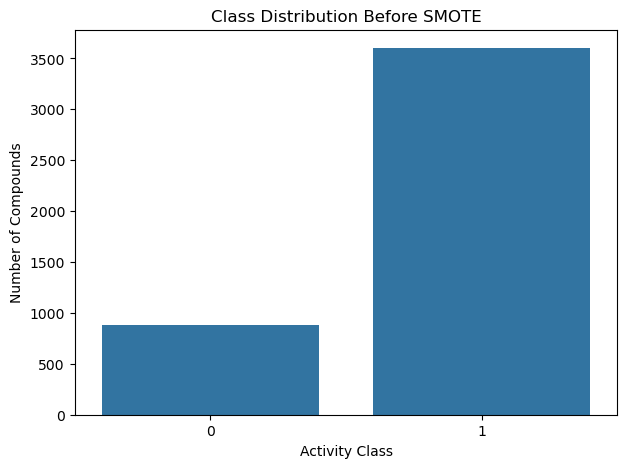

In [32]:
# Class distribution before SMOTE

plt.figure(figsize=(7, 5))

sns.countplot(x=y_train)

plt.xlabel("Activity Class")
plt.ylabel("Number of Compounds")
plt.title("Class Distribution Before SMOTE")

plt.show()

In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Activity
1    3602
0     882
Name: count, dtype: int64

After SMOTE:
Activity
1    3602
0    3602
Name: count, dtype: int64


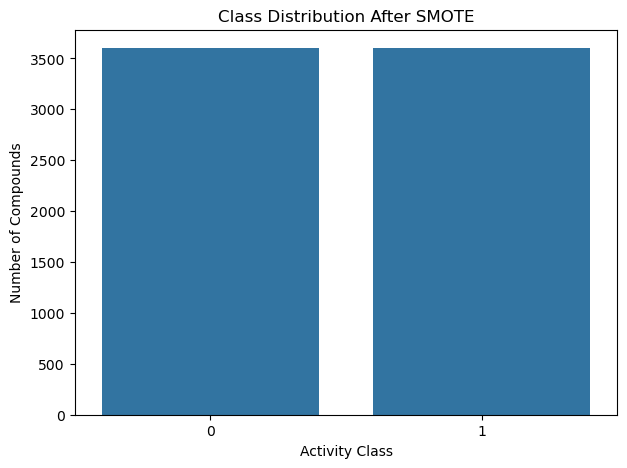

In [34]:
# Class distribution after SMOTE

plt.figure(figsize=(7, 5))

sns.countplot(x=y_train_smote)

plt.xlabel("Activity Class")
plt.ylabel("Number of Compounds")
plt.title("Class Distribution After SMOTE")

plt.show()

# logistic regression

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [36]:
scaler = StandardScaler()

X_train_sm = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

LR = LogisticRegression(max_iter=1000)

LR.fit(X_train_sm, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [37]:
LR_predict = LR.predict(X_test_scaled)

In [38]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, LR_predict))

print(classification_report(
    y_test,
    LR_predict,
    target_names=["Inactive", "Active"],
    digits=4
))

Accuracy_score = 0.8333333333333334
              precision    recall  f1-score   support

    Inactive     0.5752    0.5882    0.5817       221
      Active     0.8984    0.8935    0.8959       901

    accuracy                         0.8333      1122
   macro avg     0.7368    0.7408    0.7388      1122
weighted avg     0.8348    0.8333    0.8340      1122



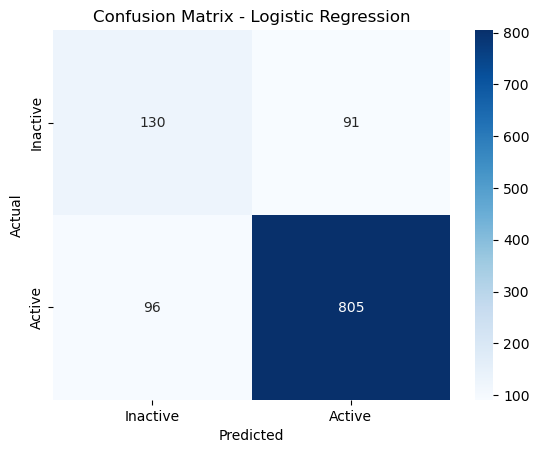

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, LR_predict)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

LR ROC AUC = 0.812


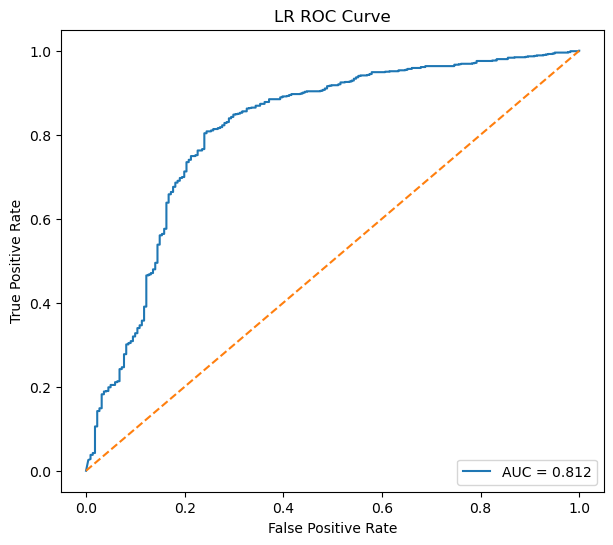

In [40]:
from sklearn.metrics import roc_curve, auc

LR_prob = LR.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    LR_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LR ROC Curve")

plt.legend(loc="lower right")

print("LR ROC AUC = %.3f" % roc_auc)

plt.show()

# decision tree

In [41]:
from sklearn.tree import DecisionTreeClassifier

In [42]:
DT = DecisionTreeClassifier(
    random_state=42
)

DT.fit(
    X_train_smote,
    y_train_smote
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
DT_predict = DT.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, DT_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        DT_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy_score = 0.8181818181818182

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.5326    0.6290    0.5768       221
      Active     0.9048    0.8646    0.8842       901

    accuracy                         0.8182      1122
   macro avg     0.7187    0.7468    0.7305      1122
weighted avg     0.8315    0.8182    0.8237      1122



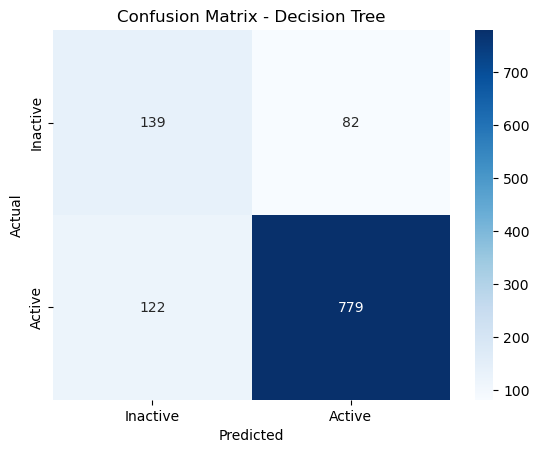

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    DT_predict
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

Decision Tree ROC AUC = 0.746


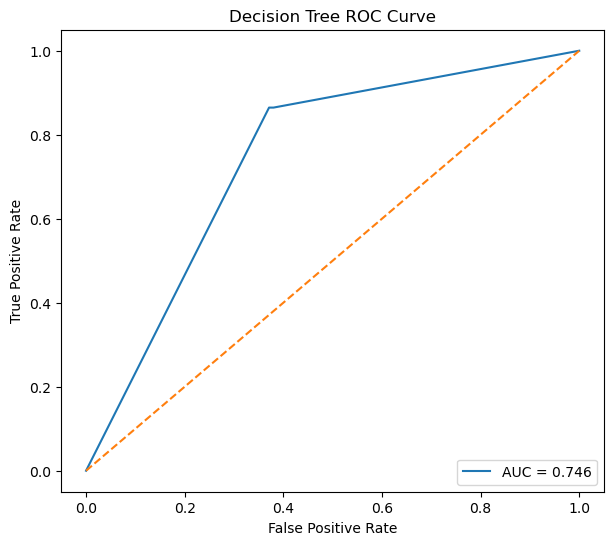

In [46]:
from sklearn.metrics import roc_curve, auc

DT_prob = DT.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    DT_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")

plt.legend(loc="lower right")

print("Decision Tree ROC AUC = %.3f" % roc_auc)

plt.show()

# random forest

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
RF = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

RF.fit(
    X_train_smote,
    y_train_smote
)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
RF_predict = RF.predict(X_test)

In [50]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, RF_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        RF_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy_score = 0.8850267379679144

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.7300    0.6606    0.6936       221
      Active     0.9187    0.9401    0.9292       901

    accuracy                         0.8850      1122
   macro avg     0.8243    0.8004    0.8114      1122
weighted avg     0.8815    0.8850    0.8828      1122



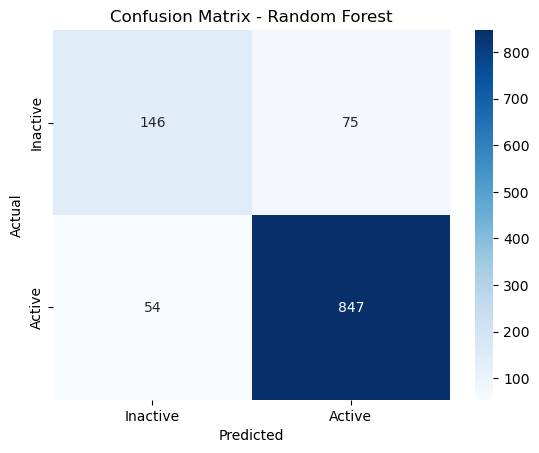

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    RF_predict
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

Random Forest ROC AUC = 0.913


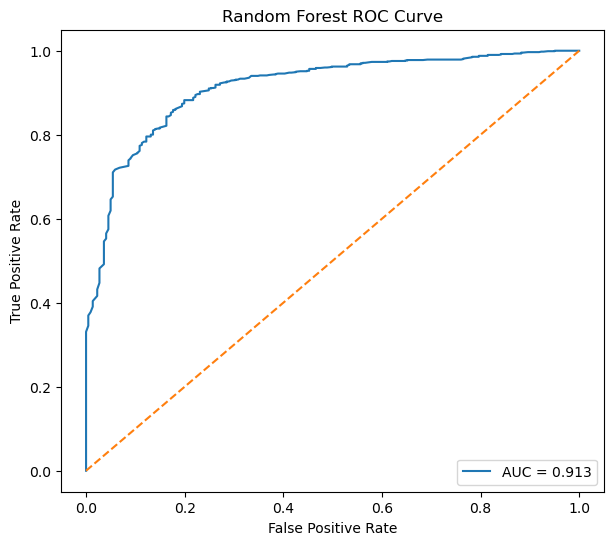

In [52]:
from sklearn.metrics import roc_curve, auc

RF_prob = RF.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    RF_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")

plt.legend(loc="lower right")

print("Random Forest ROC AUC = %.3f" % roc_auc)

plt.show()

# XGBOOST

In [53]:
from xgboost import XGBClassifier

In [54]:
XGB = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

XGB.fit(
    X_train_smote,
    y_train_smote
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [55]:
XGB_predict = XGB.predict(X_test)

In [56]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, XGB_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        XGB_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy_score = 0.8707664884135472

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.6863    0.6335    0.6588       221
      Active     0.9118    0.9290    0.9203       901

    accuracy                         0.8708      1122
   macro avg     0.7990    0.7812    0.7896      1122
weighted avg     0.8673    0.8708    0.8688      1122



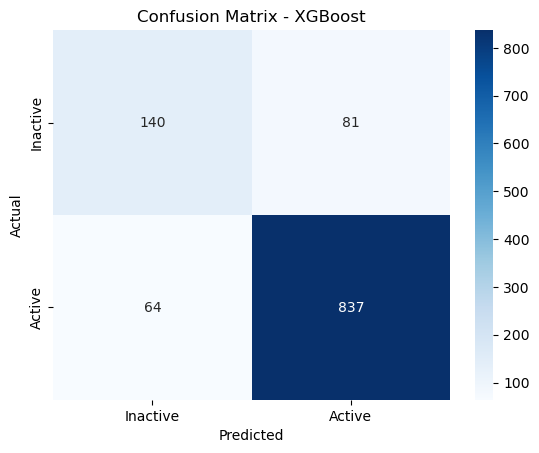

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    XGB_predict
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

XGBoost ROC AUC = 0.886


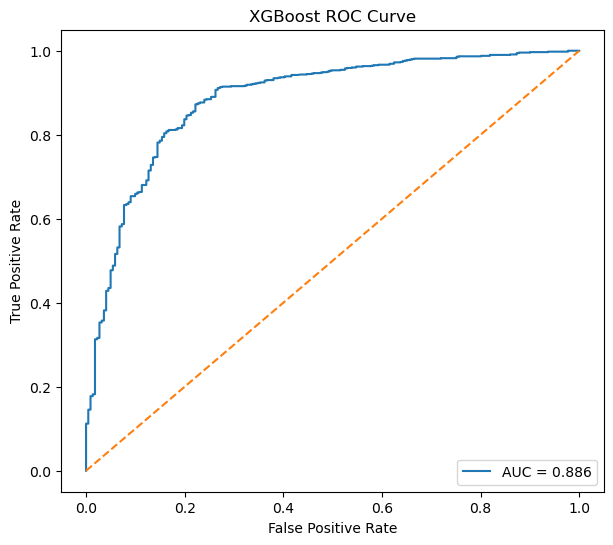

In [58]:
from sklearn.metrics import roc_curve, auc

XGB_prob = XGB.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    XGB_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")

plt.legend(loc="lower right")

print("XGBoost ROC AUC = %.3f" % roc_auc)

plt.show()

# support vector machine

In [59]:
from sklearn.svm import SVC

In [60]:
SVM = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

SVM.fit(
    X_train_sm,
    y_train_smote
)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [61]:
SVM_predict = SVM.predict(X_test_scaled)

SVM ROC AUC = 0.874


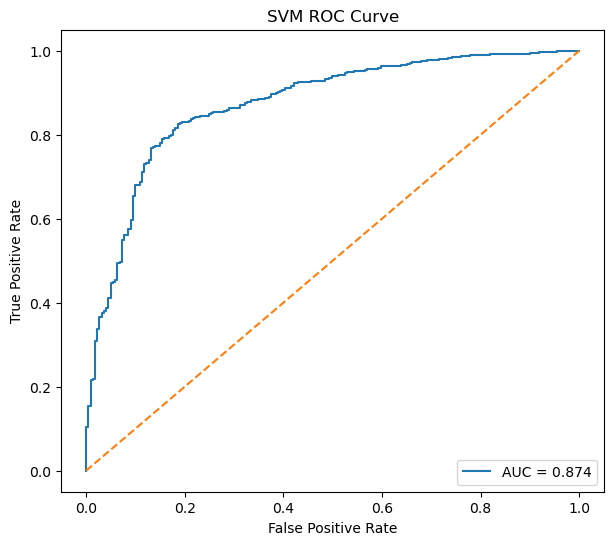

In [62]:
from sklearn.metrics import roc_curve, auc

SVM_prob = SVM.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    SVM_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")

plt.legend(loc="lower right")
print("SVM ROC AUC = %.3f" % roc_auc)

plt.show()

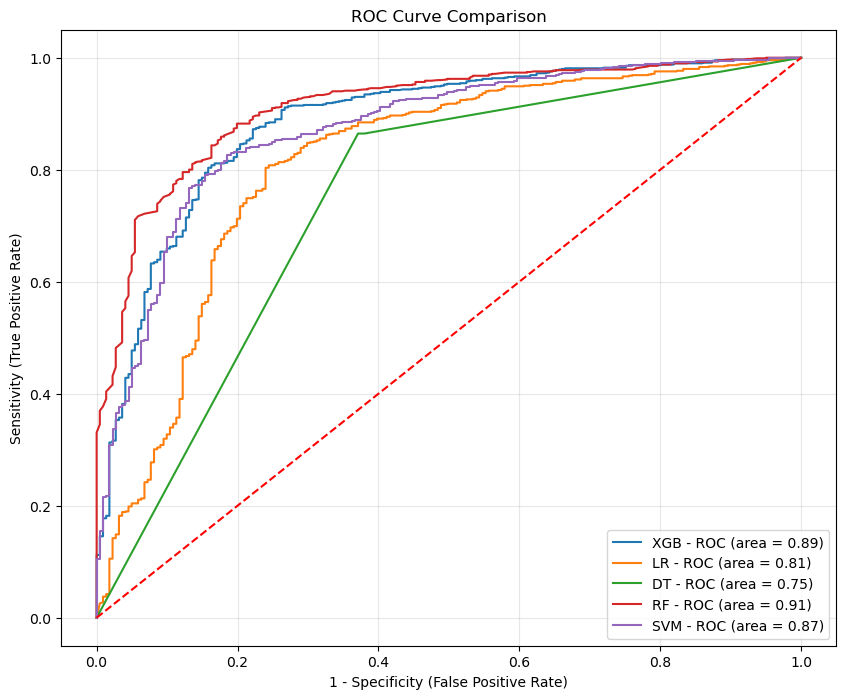

Logistic Regression AUC: 0.812
Decision Tree AUC: 0.746
Random Forest AUC: 0.913
XGBoost AUC: 0.886
SVM AUC: 0.874


In [63]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability predictions for each model
LR_prob = LR.predict_proba(X_test_scaled)[:, 1]
DT_prob = DT.predict_proba(X_test)[:, 1]
RF_prob = RF.predict_proba(X_test)[:, 1]
XGB_prob = XGB.predict_proba(X_test)[:, 1]
SVM_prob = SVM.predict_proba(X_test_scaled)[:, 1]


# Calculate ROC curves
fpr_LR, tpr_LR, _ = roc_curve(y_test, LR_prob)
fpr_DT, tpr_DT, _ = roc_curve(y_test, DT_prob)
fpr_RF, tpr_RF, _ = roc_curve(y_test, RF_prob)
fpr_XGB, tpr_XGB, _ = roc_curve(y_test, XGB_prob)
fpr_SVM, tpr_SVM, _ = roc_curve(y_test, SVM_prob)


# Calculate AUC
auc_LR = auc(fpr_LR, tpr_LR)
auc_DT = auc(fpr_DT, tpr_DT)
auc_RF = auc(fpr_RF, tpr_RF)
auc_XGB = auc(fpr_XGB, tpr_XGB)
auc_SVM = auc(fpr_SVM, tpr_SVM)


# Plot ROC curves
plt.figure(figsize=(10, 8))

plt.plot(
    fpr_XGB, tpr_XGB,
    label="XGB - ROC (area = %.2f)" % auc_XGB
)
plt.plot(
     fpr_LR, tpr_LR,
    label="LR - ROC (area = %.2f)" % auc_LR
)

plt.plot(
    fpr_DT, tpr_DT,
    label="DT - ROC (area = %.2f)" % auc_DT
)

plt.plot(
    fpr_RF, tpr_RF,
    label="RF - ROC (area = %.2f)" % auc_RF
)

plt.plot(
    fpr_SVM, tpr_SVM,
    label="SVM - ROC (area = %.2f)" % auc_SVM
)


# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    "r--"
)


plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (True Positive Rate)")
plt.title("ROC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True, alpha=0.3)
plt.show()


# Print AUC values
print("Logistic Regression AUC:", round(auc_LR, 3))
print("Decision Tree AUC:", round(auc_DT, 3))
print("Random Forest AUC:", round(auc_RF, 3))
print("XGBoost AUC:", round(auc_XGB, 3))
print("SVM AUC:", round(auc_SVM, 3))

# RFECV value

In [64]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# SMOTE + Random Forest
rfecv_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", rf_model)
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# RFECV
rfecv = RFECV(
    estimator=rfecv_pipeline,
    step=50,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    min_features_to_select=10,
    importance_getter="named_steps.rf.feature_importances_"
)

# Run RFECV ONLY on training data
rfecv.fit(X_train, y_train)

print("Optimal number of features:", rfecv.n_features_)

Optimal number of features: 953


In [65]:
selected_features = X_train.columns[rfecv.support_]

selected_features_df = pd.DataFrame({
    "feature": selected_features
})

selected_features_df.to_csv(
    "rfecv_selected_featuresAche1.csv",
    index=False
)

print("Selected features saved:", len(selected_features))

Selected features saved: 953


In [66]:
import pandas as pd

# ============================================
# AChE1 - APPLY SELECTED FEATURES TO EXTERNAL DATA
# ============================================

# Load external compounds
external_df = pd.read_csv("atompair_addedBrain.csv")

# Load the 953 selected AChE1 features
selected_df = pd.read_csv(
    "rfecv_selected_featuresAche1.csv"
)

selected_features = selected_df["feature"].tolist()

print("AChE1 selected features:", len(selected_features))

# Check whether all selected features exist
missing_features = [
    f for f in selected_features
    if f not in external_df.columns
]

print("Missing features:", len(missing_features))

if len(missing_features) == 0:
    print("✅ All 953 AChE1 features are available.")

# Keep ONLY the selected features
X_external_AChE1 = external_df[selected_features]

print("External AChE1 matrix:", X_external_AChE1.shape)

AChE1 selected features: 953
Missing features: 0
✅ All 953 AChE1 features are available.
External AChE1 matrix: (77, 953)


In [67]:
# Check the RFECV final estimator

ache1_selected_rf = rfecv.estimator_

print("AChE1 selected features:", rfecv.n_features_)
print("Features expected by final RF:", ache1_selected_rf.n_features_in_)
print("Model type:", type(ache1_selected_rf))

AChE1 selected features: 953
Features expected by final RF: 953
Model type: <class 'imblearn.pipeline.Pipeline'>


In [68]:
# ============================================
# AChE1 - PREDICT 77 EXTERNAL COMPOUNDS
# ============================================

AChE1_prediction = ache1_selected_rf.predict(
    X_external_AChE1
)

AChE1_probability = ache1_selected_rf.predict_proba(
    X_external_AChE1
)[:, 1]

print("✅ AChE1 prediction completed")
print("Compounds predicted:", len(AChE1_prediction))

C:\Users\sahan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
C:\Users\sahan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


✅ AChE1 prediction completed
Compounds predicted: 77


In [69]:
# ============================================
# AChE1 - FINAL TOP 20 UNIQUE HITS
# ============================================

# Start with all 77 external compounds
AChE1_results = external_df.copy()

# Add model prediction and probability
AChE1_results["Prediction"] = AChE1_prediction
AChE1_results["Probability"] = AChE1_probability

# Highest probability first
AChE1_results = AChE1_results.sort_values(
    by="Probability",
    ascending=False
).reset_index(drop=True)

# Remove exact duplicate SMILES
AChE1_unique = AChE1_results.drop_duplicates(
    subset="smiles",
    keep="first"
).reset_index(drop=True)

# Select 20 highest-scoring UNIQUE compounds
top20_AChE1 = AChE1_unique.head(20).copy()

# Add rank
top20_AChE1.insert(
    0,
    "Rank",
    range(1, len(top20_AChE1) + 1)
)

print("Original compounds:", len(AChE1_results))
print("Unique compounds:", len(AChE1_unique))
print("FINAL AChE1 TOP 20:", len(top20_AChE1))

# Verify there are NO duplicate SMILES
print(
    "Duplicate SMILES in final:",
    top20_AChE1["smiles"].duplicated().sum()
)

# Display
display(
    top20_AChE1[
        ["Rank", "smiles", "Prediction", "Probability"]
    ]
)

Original compounds: 77
Unique compounds: 56
FINAL AChE1 TOP 20: 20
Duplicate SMILES in final: 0


,Rank,smiles,Prediction,Probability
0,1,COc1cc2c(cc1OC)C(=O)C(CC1CCNCC1)C2,1,0.85900
1,2,CCCCNCc1cc(=O)oc2cc(OC)ccc12,1,0.82000
2,3,Cc1ccc(NCCCN)c([N+](=O)[O-])c1,1,0.81000
3,4,CNCc1cc(=O)oc2cc(OC)ccc12,1,0.78000
4,5,C[C@H](CCCN)Nc1ccnc2cc(Cl)ccc12,1,0.77500
5,6,CCNCc1cc(=O)oc2cc(OC)ccc12,1,0.75500
6,7,CCOc1ccc2nc3cc(N)ccc3c(N)c2c1,1,0.74000
7,8,CNCCC[C@](C#N)(c1ccc(OC)c(OC)c1)C(C)C,1,0.74000
8,9,Cc1cccc(C)c1NC(=O)C1CCCCN1C,1,0.73500
9,10,COc1cc(NC(C)CCCN)c2ncccc2c1,1,0.72750


In [70]:
# ============================================
# SAVE FINAL AChE1 TOP 20
# ============================================

top20_AChE1.to_excel(
    "TOP20_AChE1_Hits_Final.xlsx",
    index=False,
    engine="openpyxl"
)

print("✅ FINAL AChE1 TOP 20 SAVED")
print("Rows:", len(top20_AChE1))
print("Columns:", len(top20_AChE1.columns))
print("File: TOP20_AChE1_Hits_Final.xlsx")

✅ FINAL AChE1 TOP 20 SAVED
Rows: 20
Columns: 3100
File: TOP20_AChE1_Hits_Final.xlsx
